In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn import preprocessing, impute, metrics, model_selection
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv(r"C:\Users\Student\Desktop\Sleep.csv", index_col="Person ID")
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [11]:
df["Sleep Disorder"].value_counts()

None           219
Sleep Apnea     78
Insomnia        77
Name: Sleep Disorder, dtype: int64

In [3]:
df.dtypes

Person ID                    int64
Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                object
Blood Pressure              object
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder              object
dtype: object

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           374 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [5]:
print(df.isnull().sum())

Person ID                  0
Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category               0
Blood Pressure             0
Heart Rate                 0
Daily Steps                0
Sleep Disorder             0
dtype: int64


In [6]:
df[['Systolic','Diastolic']]=df['Blood Pressure'].str.split('/',expand=True).astype(int)

In [7]:
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Systolic,Diastolic
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None,126,83
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None,125,80
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None,125,80
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90


In [8]:
df.drop('Blood Pressure',axis=1,inplace=True)

In [9]:
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic,Diastolic
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,None,126,83
1,2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,None,125,80
2,3,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,None,125,80
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90


In [10]:
df.drop_duplicates(inplace=True)

In [13]:
df.reset_index(drop=True,inplace=True)

In [15]:
df["Sleep Disorder"].value_counts()

None           219
Sleep Apnea     78
Insomnia        77
Name: Sleep Disorder, dtype: int64

In [17]:
maping={"None":0,"Sleep Apnea":1,"Insomnia":2}
df["Sleep Disorder"]=df["Sleep Disorder"].replace(maping)

In [18]:
df["Gender"].value_counts()

Male      189
Female    185
Name: Gender, dtype: int64

In [20]:
maping={"Male":0,"Female":1}
df["Gender"]=df["Gender"].replace(maping)

In [22]:
df["BMI Category"].value_counts()

Normal           195
Overweight       148
Normal Weight     21
Obese             10
Name: BMI Category, dtype: int64

In [23]:
maping={"Overweight":0,"Normal":1,"Obese":2,"Normal Weight":1}
df["BMI Category"]=df["BMI Category"].replace(maping)

In [25]:
df["Occupation"].value_counts()

Nurse                   73
Doctor                  71
Engineer                63
Lawyer                  47
Teacher                 40
Accountant              37
Salesperson             32
Software Engineer        4
Scientist                4
Sales Representative     2
Manager                  1
Name: Occupation, dtype: int64

In [32]:
maping={'Nurse':0,'Doctor':1,'Engineer':2,'Lawyer':3,'Teacher':4,'Accountant':5,'Salesperson':6,
                            'Software Engineer':7,'Scientist':8,'Sales Representative':9,'Manager':10}
df["Occupation"]=df["Occupation"].replace(maping)

In [33]:
df.dtypes

Person ID                    int64
Gender                       int64
Age                          int64
Occupation                   int64
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                 int64
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder               int64
Systolic                     int32
Diastolic                    int32
dtype: object

In [34]:
df

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic,Diastolic
0,1,0,27,7,6.1,6,42,6,0,77,4200,0,126,83
1,2,0,28,1,6.2,6,60,8,1,75,10000,0,125,80
2,3,0,28,1,6.2,6,60,8,1,75,10000,0,125,80
3,4,0,28,9,5.9,4,30,8,2,85,3000,1,140,90
4,5,0,28,9,5.9,4,30,8,2,85,3000,1,140,90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,1,59,0,8.1,9,75,3,0,68,7000,1,140,95
370,371,1,59,0,8.0,9,75,3,0,68,7000,1,140,95
371,372,1,59,0,8.1,9,75,3,0,68,7000,1,140,95
372,373,1,59,0,8.1,9,75,3,0,68,7000,1,140,95


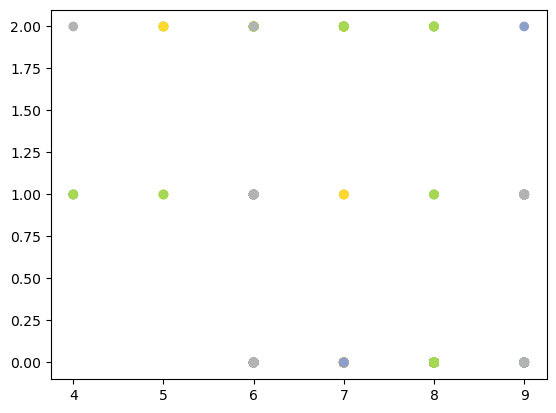

In [52]:
plt.scatter(df["Quality of Sleep"],df["Sleep Disorder"],cmap="Set2",c=df["Systolic"])
plt.show()

In [41]:
correlation=df.corr()
correlation

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic,Diastolic
Person ID,1.000000,0.584229,0.990516,-0.177659,0.296305,0.431612,0.149882,-0.394287,-0.527081,-0.225467,0.043844,0.341406,0.611551,0.590670
Gender,0.584229,1.000000,0.596358,-0.106312,0.121579,0.291366,-0.001454,-0.396018,-0.367180,-0.217105,0.014509,0.161131,0.210527,0.268378
Age,0.990516,0.596358,1.000000,-0.233245,0.344709,0.473734,0.178993,-0.422344,-0.510885,-0.225606,0.057973,0.303962,0.605878,0.593839
Occupation,-0.177659,-0.106312,-0.233245,1.000000,-0.236927,-0.194516,-0.371149,0.000155,-0.048480,0.005883,-0.331313,0.249023,-0.273148,-0.326692
Sleep Duration,0.296305,0.121579,0.344709,-0.236927,1.000000,0.883213,0.212360,-0.811023,0.325933,-0.516455,-0.039533,-0.382045,-0.180406,-0.166570
Quality of Sleep,0.431612,0.291366,0.473734,-0.194516,0.883213,1.000000,0.192896,-0.898752,0.218094,-0.659865,0.016791,-0.357477,-0.121632,-0.110151
Physical Activity Level,0.149882,-0.001454,0.178993,-0.371149,0.212360,0.192896,1.000000,-0.034134,-0.083444,0.136971,0.772723,-0.109225,0.265416,0.382651
Stress Level,-0.394287,-0.396018,-0.422344,0.000155,-0.811023,-0.898752,-0.034134,1.000000,-0.134970,0.670026,0.186829,0.181296,0.102818,0.091811
BMI Category,-0.527081,-0.367180,-0.510885,-0.048480,0.325933,0.218094,-0.083444,-0.134970,1.000000,0.031308,-0.175279,-0.580080,-0.552555,-0.619888
Heart Rate,-0.225467,-0.217105,-0.225606,0.005883,-0.516455,-0.659865,0.136971,0.670026,0.031308,1.000000,-0.030309,0.220913,0.294143,0.271092


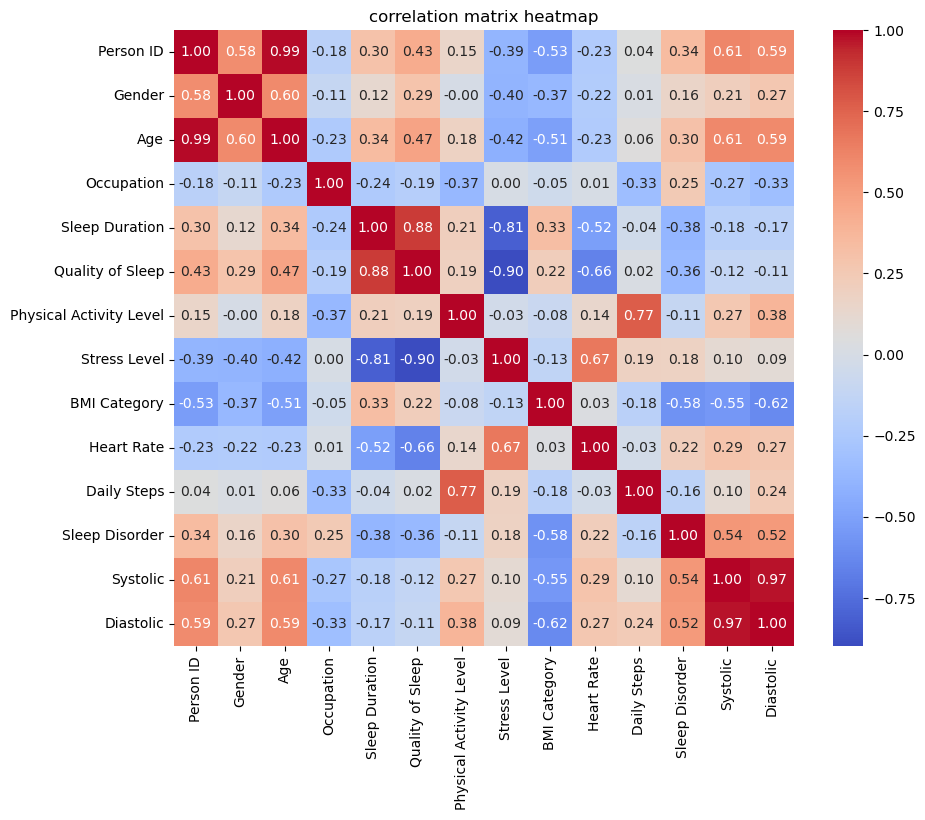

In [46]:
plt.figure(figsize=(10,8))
sb.heatmap(correlation,annot=True,cmap="coolwarm",fmt=".2f")
plt.title("correlation matrix heatmap")
plt.show()

In [47]:
df.columns

Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Heart Rate', 'Daily Steps', 'Sleep Disorder',
       'Systolic', 'Diastolic'],
      dtype='object')

In [48]:
x=df[['Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Heart Rate', 'Daily Steps',
       'Systolic', 'Diastolic']].values
y=df['Sleep Disorder']

In [51]:
x_train,x_test,y_train,y_test=model_selection.train_test_split(x,y,test_size=0.3
                                                               ,random_state=42,stratify=y)

In [55]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

x_train_scaled

array([[ 1.05111308, -0.56888026,  1.1606532 , ...,  0.11995809,
        -1.74783656, -1.57886638],
       [-0.95137242,  0.2566513 ,  1.64456771, ..., -0.49636201,
         0.17645482,  0.04543053],
       [-0.95137242, -0.80474642, -0.29109034, ..., -1.11268211,
        -0.46497564, -0.76671792],
       ...,
       [-0.95137242, -1.04061257, -0.77500485, ..., -1.11268211,
        -0.46497564, -0.76671792],
       [ 1.05111308,  0.96424978, -1.25891936, ...,  1.96891839,
         1.45931573,  1.66972743],
       [-0.95137242, -0.45094718,  0.19282417, ...,  0.73627819,
         0.17645482,  0.04543053]])

In [95]:
train=[]
test=[]

In [96]:
cv_score = []
for k in range(1,11):
    knn = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn,x,y , cv=5 , scoring="accuracy")
    cv_score.append(score.mean())
    
k_range = range(1,11)
best_k = k_range[np.argmax(cv_score)]
best_k

7

In [97]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(x_train_scaled,y_train)

KNeighborsClassifier(n_neighbors=7)

In [98]:
y_pred_test = knn.predict(x_test_scaled)
y_pred_train = knn.predict(x_train_scaled)

In [100]:
train_score = knn.score(x_train_scaled , y_train)
test_score = knn.score(x_test_scaled , y_test)
train.append(train_score)
test.append(test_score)
print(round(train_score,2) , round(test_score,2))

0.9 0.89


In [88]:
Lr=LogisticRegression()
Lr.fit(x_train_scaled,y_train)
y_pred=Lr.predict(x_test_scaled)
metrics.accuracy_score(y_test,y_pred)

0.8938053097345132

In [101]:
train_score = Lr.score(x_train_scaled , y_train)
test_score = Lr.score(x_test_scaled , y_test)
train.append(train_score)
test.append(test_score)
print(round(train_score,2) , round(test_score,2))

0.92 0.89


In [90]:
SVM=SVC()
SVM.fit(x_train_scaled,y_train)
y_pred=SVM.predict(x_test_scaled)
metrics.accuracy_score(y_test,y_pred)

0.8938053097345132

In [102]:
train_score = SVM.score(x_train_scaled , y_train)
test_score = SVM.score(x_test_scaled , y_test)
train.append(train_score)
test.append(test_score)
print(round(train_score,2) , round(test_score,2))

0.93 0.89


In [92]:
dt=DecisionTreeClassifier()
dt.fit(x_train_scaled,y_train)
y_pred=dt.predict(x_test_scaled)
metrics.accuracy_score(y_test,y_pred)

0.8584070796460177

In [103]:
train_score = dt.score(x_train_scaled , y_train)
test_score = dt.score(x_test_scaled , y_test)
train.append(train_score)
test.append(test_score)
print(round(train_score,2) , round(test_score,2))

0.95 0.86


In [104]:
train

[0.9042145593869731, 0.9157088122605364, 0.9310344827586207, 0.946360153256705]

In [105]:
test

[0.8938053097345132,
 0.8938053097345132,
 0.8938053097345132,
 0.8584070796460177]

In [106]:
model=["knn","logistic","svm","decision tree"]

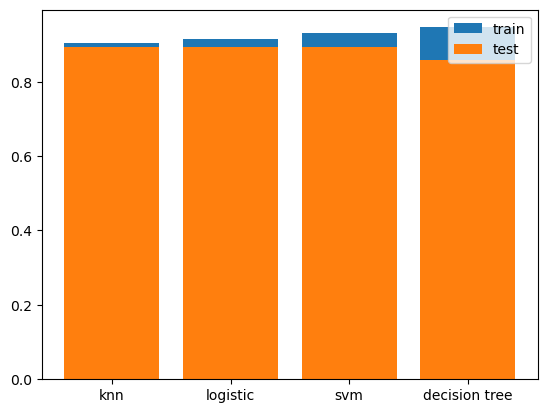

In [108]:
plt.bar(model,train,label="train")
plt.bar(model,test,label="test")
plt.legend()
plt.show()